# GigaTIME-flash Inference

This notebook shows how to load **GigaTIME-flash** from the HuggingFace model card
and run inference on H&E tiles to generate virtual 23-channel mIF maps.

GigaTIME-flash is a lightweight variant of GigaTIME: a GigaPath-mini / DINOv2-small
LoRA encoder with a convolutional decoder. The model takes H&E `[B, 3, 256, 256]`
tiles and outputs mIF `[B, 23, 256, 256]` maps.

> This is an inference-only tutorial. For training, see `gigatime_training.ipynb`.

Requirements Import

In [1]:
import os
import glob

import numpy as np
import torch
from torch import nn
from PIL import Image

from timm.layers import SwiGLUPacked
from timm.models.vision_transformer import _create_vision_transformer

SEED = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

print("Torch:", torch.__version__, "| Using device:", device)

/Users/jeyamariajose/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.8.0 | Using device: cpu


Channel names

The output channel order. `TRITC` and `Cy5` are background channels that are not
used in the downstream analysis.

In [2]:
CHANNEL_NAMES = [
    "DAPI", "TRITC", "Cy5", "PD-1_1:200", "CD14", "CD4", "T-bet", "CD34",
    "CD68_1:100", "CD16", "CD11c", "CD138", "CD20", "CD3_1:1000", "CD8",
    "PD-L1", "CK_1:150", "Ki67_1:150", "Tryptase", "Actin-D", "Caspase3-D",
    "PHH3-B", "Transgelin",
]
common_channel_list = CHANNEL_NAMES
print(len(CHANNEL_NAMES), "channels")

23 channels


Model architecture (GigaTIME-flash)

The GigaTIME-flash encoder is a DINOv2-small ViT with LoRA adapters, paired with a
convolutional decoder that uses skip connections from intermediate transformer blocks.

In [3]:
class LoraConfig:
    def __init__(self, r=8, lora_alpha=16, lora_dropout=0.1, target_modules=None):
        self.r = r
        self.lora_alpha = lora_alpha
        self.lora_dropout = lora_dropout
        self.target_modules = target_modules or []


class LoRALinear(nn.Module):
    def __init__(self, base_layer, config):
        super().__init__()
        self.base_layer = base_layer
        self.scaling = {"default": config.lora_alpha / config.r}
        self.lora_dropout = nn.ModuleDict({"default": nn.Dropout(config.lora_dropout)})
        self.lora_A = nn.ModuleDict({"default": nn.Linear(base_layer.in_features, config.r, bias=False)})
        self.lora_B = nn.ModuleDict({"default": nn.Linear(config.r, base_layer.out_features, bias=False)})

    @property
    def weight(self):
        return self.base_layer.weight

    @property
    def bias(self):
        return self.base_layer.bias

    def forward(self, x):
        result = self.base_layer(x)
        update = self.lora_B["default"](self.lora_A["default"](self.lora_dropout["default"](x)))
        return result + update * self.scaling["default"]


class BaseModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model


class PeftFallbackModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.base_model = BaseModelWrapper(model)

    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.base_model.model, name)

    def forward(self, *args, **kwargs):
        return self.base_model.model(*args, **kwargs)


def apply_lora(module, config):
    for child_name, child in list(module.named_children()):
        if child_name in config.target_modules and isinstance(child, nn.Linear):
            setattr(module, child_name, LoRALinear(child, config))
        else:
            apply_lora(child, config)


def make_vit_small_patch16_dinov2():
    model_args = dict(
        patch_size=16, embed_dim=384, depth=12, num_heads=6, init_values=1e-5,
        mlp_ratio=2.66667 * 2, mlp_layer=SwiGLUPacked, act_layer=nn.SiLU, img_size=224,
    )
    return _create_vision_transformer("vit_small_patch14_dinov2", pretrained=False, **model_args)

In [4]:
class GigaTIMEFlash(nn.Module):
    def __init__(self, num_classes=23):
        super().__init__()
        vit_encoder = make_vit_small_patch16_dinov2()
        config = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.1, target_modules=["qkv", "proj"])
        apply_lora(vit_encoder, config)
        self.encoder = PeftFallbackModel(vit_encoder)
        self.num_classes = num_classes

        self.decoder4 = self._decoder_block(384, 192)
        self.decoder3 = self._decoder_block(192, 96)
        self.decoder2 = self._decoder_block(96, 48)
        self.decoder1 = self._decoder_block(48, 24)

        self.skip1 = self._skip_block(384, 48, 3)
        self.skip2 = self._skip_block(384, 96, 2)
        self.skip3 = self._skip_block(384, 192, 1)
        self.final_conv = nn.Conv2d(24, num_classes, kernel_size=1)

        self.encoder.patch_embed.img_size = (256, 256)
        self.encoder.patch_embed.grid_size = (16, 16)
        self.encoder.patch_embed.num_patches = 256

    @staticmethod
    def _decoder_block(in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True),
        )

    @staticmethod
    def _skip_block(in_channels, out_channels, times):
        layers = []
        for _ in range(times):
            layers.append(nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2))
            in_channels = out_channels
        return nn.Sequential(*layers)

    @staticmethod
    def _tokens_to_patch(x):
        batch_size, num_tokens, channels = x.shape
        grid = int(num_tokens ** 0.5)
        if grid * grid != num_tokens:
            raise ValueError(f"Expected square patch tokens, got {num_tokens}")
        return x.permute(0, 2, 1).contiguous().view(batch_size, channels, grid, grid)

    @staticmethod
    def _resize_pos_embed(pos_embed, new_grid_size):
        cls_tok, grid_tok = pos_embed[:, :1], pos_embed[:, 1:]
        old_num = int(grid_tok.shape[1] ** 0.5)
        grid_tok = grid_tok.reshape(1, old_num, old_num, -1).permute(0, 3, 1, 2)
        grid_tok = torch.nn.functional.interpolate(grid_tok, size=new_grid_size, mode="bicubic", align_corners=False)
        grid_tok = grid_tok.permute(0, 2, 3, 1).reshape(1, new_grid_size[0] * new_grid_size[1], -1)
        return torch.cat((cls_tok, grid_tok), dim=1)

    def forward(self, x):
        enc_outs = []
        x = self.encoder.patch_embed(x)
        _, num_tokens, _ = x.shape
        grid = int(num_tokens ** 0.5)

        pos_emb = self._resize_pos_embed(self.encoder.pos_embed, (grid, grid))
        x = x + pos_emb[:, 1:]
        x = self.encoder.patch_drop(x)
        x = self.encoder.norm_pre(x)

        for idx, block in enumerate(self.encoder.blocks):
            x = block(x)
            if idx in {3, 5, 8, 11}:
                enc_outs.append(x)

        x = self.decoder4(self._tokens_to_patch(enc_outs[3]))
        x = self.decoder3(x + self.skip3(self._tokens_to_patch(enc_outs[2])))
        x = self.decoder2(x + self.skip2(self._tokens_to_patch(enc_outs[1])))
        x = self.decoder1(x + self.skip1(self._tokens_to_patch(enc_outs[0])))
        x = self.final_conv(x)

        if x.shape[-1] != 256:
            x = nn.functional.interpolate(x, size=(256, 256), mode="bilinear", align_corners=True)
        return x

Load the GigaTIME-flash model from HuggingFace

You need to agree to the terms to access the model. Once you have access, set your
HuggingFace read-only token as an environment variable before running this cell:

```bash
export HF_TOKEN=<huggingface read-only token>
```

In [5]:
from huggingface_hub import snapshot_download

repo_id = "prov-gigatime/GigaTIME-flash"

# Download the repo snapshot (model.pth + config.json)
local_dir = snapshot_download(repo_id=repo_id)
weights_path = os.path.join(local_dir, "model.pth")

model = GigaTIMEFlash(num_classes=len(CHANNEL_NAMES))

checkpoint = torch.load(weights_path, map_location="cpu")
if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    checkpoint = checkpoint["state_dict"]

# Remap checkpoint keys onto the model (handles module./LoRA base_layer/encoder prefixes)
model_state = model.state_dict()
loaded = {}
for key, value in checkpoint.items():
    candidates = [key]
    if key.startswith("module."):
        candidates.append(key[len("module."):])
    if ".base_layer." in key:
        candidates.append(key.replace(".base_layer.", "."))
    if key.startswith("encoder.") and not key.startswith("encoder.base_model.model."):
        candidates.append(key.replace("encoder.", "encoder.base_model.model.", 1))
    for candidate in candidates:
        if candidate in model_state and model_state[candidate].shape == value.shape:
            loaded[candidate] = value
            break

model.load_state_dict(loaded, strict=False)
model.to(device).eval()
print(f"=> loaded model {repo_id} (matched {len(loaded)} tensors)")


Fetching 5 files:   0%|                                   | 0/5 [00:00<?, ?it/s]


Fetching 5 files: 100%|████████████████████████| 5/5 [00:00<00:00, 67650.06it/s]

=> loaded model prov-gigatime/GigaTIME-flash (matched 252 tensors)


Inference function

The model runs on non-overlapping 256x256 windows. `do_inference` tiles the input,
runs the model on each window, and stitches the predicted mIF maps back together.

In [6]:
def do_inference(input_image, model, window_size=256):
    b, c, h, w = input_image.shape
    output_logits = torch.zeros(b, len(CHANNEL_NAMES), h, w, device=input_image.device)
    with torch.no_grad():
        for i in range(0, h, window_size):
            for j in range(0, w, window_size):
                window = input_image[:, :, i:i + window_size, j:j + window_size].to(device)
                logits = model(window)
                output_logits[:, :, i:i + window_size, j:j + window_size] = logits
    return output_logits


def preprocess_tile(path, input_size=512):
    image = Image.open(path).convert("RGB").resize((input_size, input_size), Image.BILINEAR)
    rgb = np.asarray(image).astype(np.float32) / 255.0
    tensor = torch.from_numpy(((rgb - mean) / std).transpose(2, 0, 1)).unsqueeze(0)
    return image, tensor

Run inference and visualize

Point `input_glob` at a folder of H&E tile PNGs. Each channel is shown in a distinct
color, following the same visualization style as the main GigaTIME notebook.

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def get_display_channels():
    exclude = ['TRITC', 'Cy5']
    indices, names = [], []
    for i, name in enumerate(CHANNEL_NAMES):
        base = name.split(' - ')[0].strip()
        if base in exclude:
            continue
        indices.append(i)
        names.append(base)
    return indices, names


def build_channel_color_map(channel_names):
    palette = plt.cm.get_cmap('tab20', max(len(channel_names), 1))
    return {name: mcolors.to_hex(palette(idx)) for idx, name in enumerate(channel_names)}


def colorize_channel(mask_2d, color_hex, background=(0.0, 0.0, 0.0)):
    color_rgb = np.array(mcolors.to_rgb(color_hex), dtype=np.float32)
    background_rgb = np.array(background, dtype=np.float32)
    mask_2d = np.clip(np.asarray(mask_2d, dtype=np.float32), 0.0, 1.0)
    return background_rgb + mask_2d[..., None] * (color_rgb - background_rgb)


def plot_prediction(he_image, pred_23hw):
    indices, names = get_display_channels()
    colors = build_channel_color_map(names)

    n_cols = 4
    n_rows = (len(indices) + 1 + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    axes[0].imshow(he_image)
    axes[0].set_title("H&E patch")
    axes[0].axis('off')

    for plot_idx, ch in enumerate(indices):
        name = names[plot_idx]
        colored = colorize_channel(pred_23hw[ch], colors[name])
        axes[plot_idx + 1].imshow(colored)
        axes[plot_idx + 1].set_title(f"Virtual mIF: {name}", color=colors[name])
        axes[plot_idx + 1].axis('off')

    for ax in axes[len(indices) + 1:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

prediction shape: (23, 512, 512)


/var/folders/bk/q6m0vp457m92dd8lx22vvw7w0000gn/T/ipykernel_43235/2940703875.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', max(len(channel_names), 1))


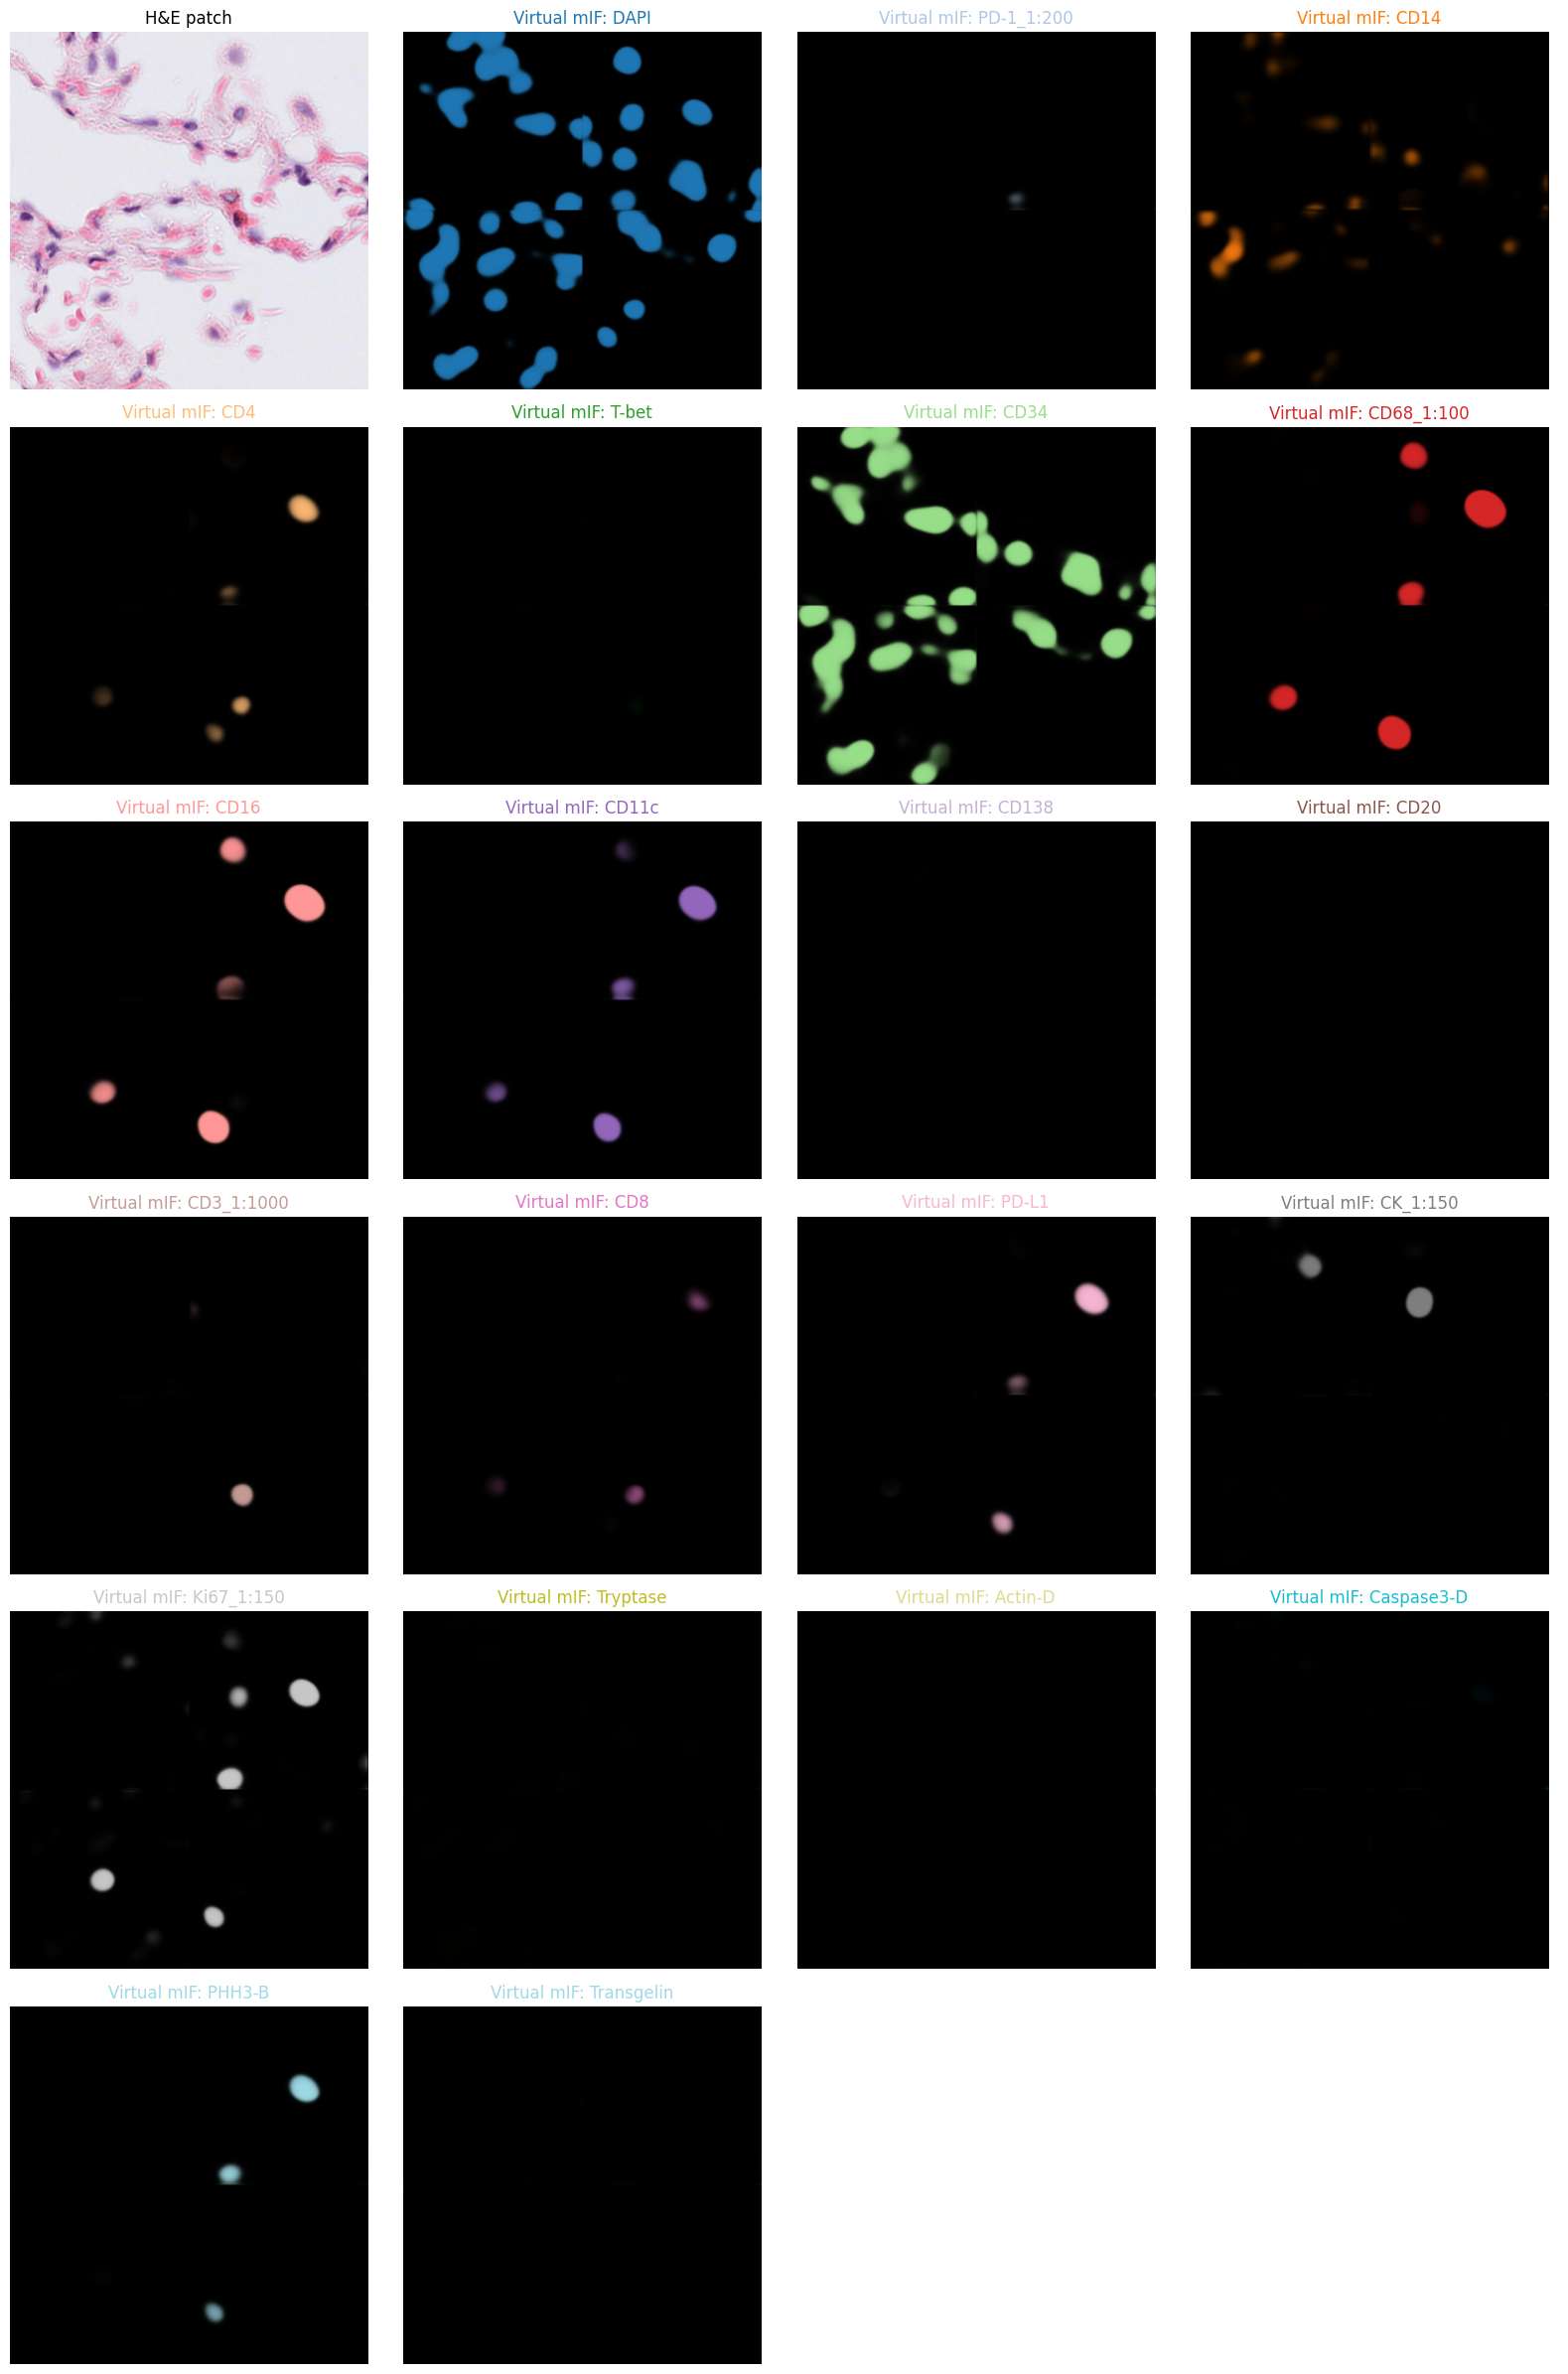

In [8]:
# Point this at your H&E tiles (e.g. the samples shipped with the inference package)
input_glob = "./../data/sample_test_data/data/*_he.png"

tile_paths = sorted(glob.glob(input_glob))
assert tile_paths, f"No H&E tiles matched: {input_glob}"

# Run on the first tile
he_image, tensor = preprocess_tile(tile_paths[0], input_size=512)
logits = do_inference(tensor.to(device), model, window_size=256)
pred = torch.sigmoid(logits).squeeze(0).cpu().numpy()

print("prediction shape:", pred.shape)
plot_prediction(he_image, pred)